In [ ]:

!pip install dynesty emcee pygtc 
!pip install pytransit
!pip install ipympl

### ONLY IF YOU ARE RUNNING ON GOOGLE COLAB
# Uncomment the following lines if you are using Google Colab
#!git clone https://github.com/LucaMalavolta/lucchin_exoplanets_handson.git
#%cd lucchin_exoplanets_handson
#from google.colab import output
#output.enable_custom_widget_manager()

  Using cached ipympl-0.10.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipympl-0.10.0-py3-none-any.whl (519 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m2/4 [ipywidgets]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

import emcee
import pytransit
from pytransit.utils.de import DiffEvol
import pickle
import pygtc
from scipy import stats
from pytransit import RoadRunnerModel
import corner
import dynesty
from matplotlib.gridspec import GridSpec
from utilities import *

In [2]:
print('numpy:    ', np.__version__)
print('emcee:    ', emcee.__version__)
print('dynesty:  ', dynesty.__version__)
print('pytransit:', pytransit.__version__)
print('pygtc:    ', pygtc.__version__)

numpy:     2.4.6
emcee:     3.1.6
dynesty:   3.0.0
pytransit: 2.7.1
pygtc:     0.5.0


In [3]:
file_list = [
'sector_017',
'sector_021',
'sector_024',
'sector_025',
'sector_041',
'sector_048',
'sector_051',
'sector_055',
'sector_056',
'sector_057',
'sector_059',
'sector_075',
'sector_076',
'sector_078',
'sector_082',
'sector_083',
'sector_084',
'sector_086'
    ]

# Your birth date
seed = int(15031984)

# Create NumPy random generator
rng = np.random.default_rng(seed)

# Generate random integers
selected_lc = rng.integers(0, len(file_list))

file_name = file_list[selected_lc]
print('Your selected sector is', file_name)

Your selected sector is sector_024


## Getting the data 
Let's load our data first.
For this hands-on, you already have TESS photometry with instrumental and astrophysical signals removed, and RV data.

Our planet is [Qatar-1b](https://exoplanetarchive.ipac.caltech.edu/overview/qatar-1), discovered by [Alsubai et al. 2011](https://ui.adsabs.harvard.edu/abs/2011MNRAS.417..709A/abstract).

THe TESS data is taken from the [Mikulski Archive for Space Telescopes (MAST) Portal at STScI](https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html).

The RV data is taken from [Covino et al. 2013](https://ui.adsabs.harvard.edu/abs/2013A&A...554A..28C/abstract)

It's alsways good to have a look at your data to check out for strange things...

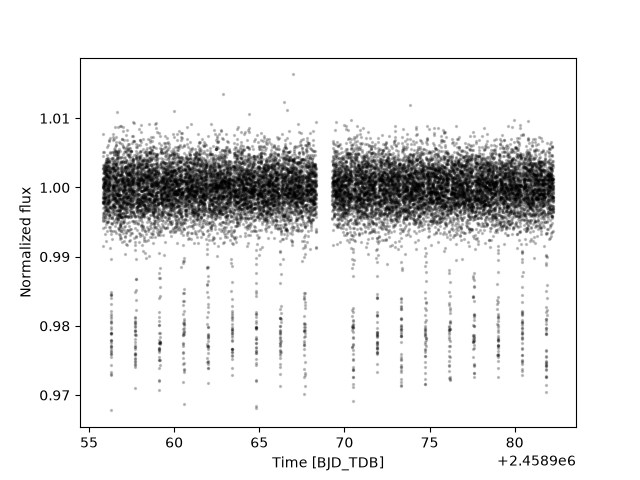

In [4]:
data_lc = np.genfromtxt('data/' + file_name+'_pdcsap_processed.dat', names=True)
time = data_lc['time']
flux = data_lc['value']
ferr = data_lc['error']

plt.figure()
plt.scatter(data_lc['time'], data_lc['value'], c='k', s=2, alpha=0.2)
plt.xlabel('Time [BJD_TDB]')
plt.ylabel('Normalized flux')
plt.show()


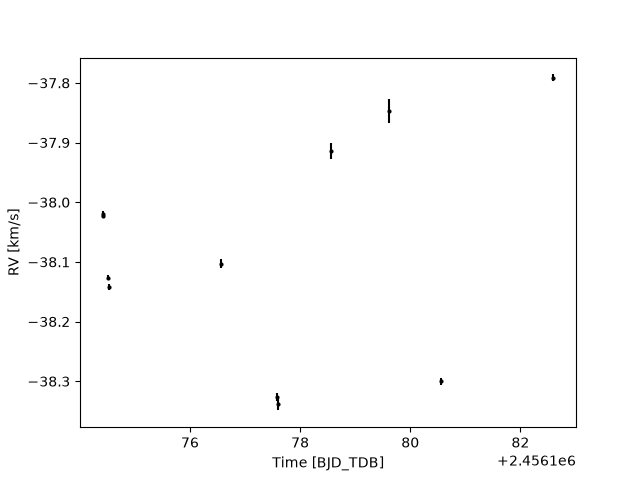

In [5]:

data_rv = np.genfromtxt('data/radial_velocities.dat', names=True)

plt.figure()
plt.errorbar(data_rv['time'], data_rv['value'],yerr=data_rv['error'], fmt='o', color='k', markersize=2)
plt.xlabel('Time [BJD_TDB]')
plt.ylabel('RV [km/s]')
plt.show()


## Parameters of the model

As we have seen in the previous lecture, our model of the transit encompassed the following parameters:

0) `t0` : time of inferior conjunction
1) `p`: orbital period of the planet, in days
2) `k`: scaled planetary radius, i.e., planet radius in units of stellar radii
3) `a`: scaled semi-major axis, i.e., semi-major axis in units of stellar radii
4) `i`: orbital inclination in degrees

We will assume that the planet is in a circular orbit, so we don't need the eccentricty or the argument of the pericente. 

We have to include two additional parameters for the limb darkening coefficients:

5) TESS limb darkening coefficient `u1`
6) TESS limb darkening coefficient `u2`

We include a *normalization factor* to ensure that the average value of th elightcurve outside of the transit is equal to zero:

7) normalization factor

Finally, we add an extra parameters, called *jitter parameter*, which is not used by the model but are instead *added in quadrature* to our error estimates. These parameters will compensate for any source of errors that we have not included in our estimates until now. An example can be found [in this paper](https://ui.adsabs.harvard.edu/abs/2020AJ....159..235L/abstract).

8) jitter parameter for TESS data

We repeat the same exercise for the RV model. Again, we assume a circular orbit, so no eccentricity or argument of the pericenter. We also note that *period* and *time of inferior conjunction* are already included in our parameter list, so we don't need to include them again. We are left with:

9) radial velocity semi-amplitude $K_p$, in m/s
10) radial velocity offset (unperturbed velocity of the star)
11) jitter parameter for RV data

We have a total of 12 parameters (remember, we started counting from zero. 

We now define the initial approximated values for our mocel:


In [6]:
theta = np.empty(12)

theta[0] = 2460533.9  #time of inferior conjunction
theta[1] = 1.4200      #orbital period
theta[2] = 0.150       #planet radius (in units of stellar radii)
theta[3] = 6.00        #semi-major axis (in units of stellar radii)
theta[4] = 84.0        #orbital inclination (in degrees)
theta[5] = 0.50        # TESS LD coeff u1
theta[6] = 0.10        # TESS LD coeff u2
theta[7] = 1.00        # normalization factor
theta[8] = 0.0001      # jitter parameter for TESS data
theta[9] = 150.0       # RV semiamplitude in m/s
theta[10] = -38.1       # RV offset in km/s
theta[11] = 1.0      # jitter parameter for RV data

labels = ['Tc', 'P', 'Rp/Rs', 'a/Rs', 'i', 'u1', 'u2', 'norm', 'TESS jitter',  'K', 'RV offset', 'RV jitter' ]


## Define the boundaries
Defining the boundaries of our parameters is not explicitly required by the sampler we employ, but it may be compulsory for other samplers. In general, proving boundaries for the parameter spaces is always helpful as it will avoid exploring unphysical parameter combinations (negative periods, negative radii...). 

The boundary array is a two-dimensional array, with one dimension equal to the number of parameters of the model and the other dimension equal to two. Written in this way, it will be trivial to check if the $\boldsymbol{\theta}$ array is within the boundaries

In [7]:
boundaries = np.empty([2, len(theta)])

boundaries[:,0] = [theta[0]-0.1, theta[0]+0.1]
boundaries[:,1] = [theta[1]-0.1, theta[1]+0.1]
boundaries[:,2] = [0.0, 0.5]
boundaries[:,3] = [0.0, 20.]
boundaries[:,4] = [80.00, 90.0]
boundaries[:,5] = [-1.00, 1.0]
boundaries[:,6] = [0.00, 1.0]
boundaries[:,7] = [0.9, 1.1]
boundaries[:,8] = [0.0, 0.01]
boundaries[:,9] = [0.0, 300.0]
boundaries[:,10] = [-38.4, -37.8]
boundaries[:,11] = [0.0, 50.0]


## Plot of the starting point

MCMC requires a starting point close enough to the initial solution. We can check how goood is the starting point by comparing our model to the data.

**Note:** initialization of the RoadRunner model may take a while

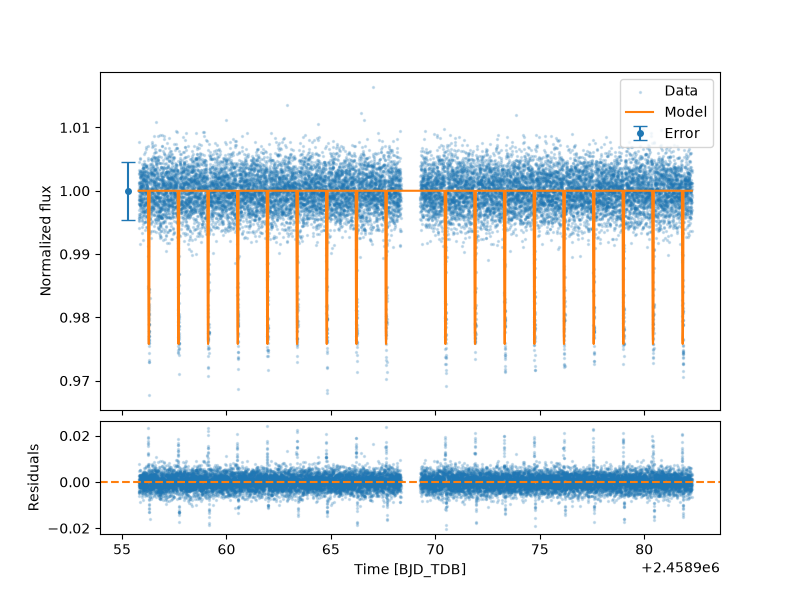

In [8]:

tm = RoadRunnerModel('quadratic')
tm.set_data(data_lc['time'])

model = tm.evaluate(t0=theta[0],
                    p=theta[1], 
                    k=theta[2],  
                    a=theta[3], 
                    i=theta[4]/180.*np.pi,
                    ldc=[theta[5], theta[6]])

plt.xlabel('Time [BJD_TDB]')
plt.ylabel('Normalized flux')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.scatter(data_lc['time'], data_lc['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(data_lc['time'], model, color='C1', label='Model')

# Plot single point with error bars
ax_main.errorbar(
    data_lc['time'][0]-0.5,
    1.0,
    yerr=np.median(data_lc['error']),
    fmt='o',          # marker style
    capsize=5,        # size of error bar caps
    markersize=4,
    label='Error'
)
ax_main.set_ylabel('Normalized flux')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)


# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.scatter(data_lc['time'], data_lc['value']-model,  s=2, alpha=0.2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Time [BJD_TDB]')
ax_res.set_ylabel('Residuals')

plt.show()


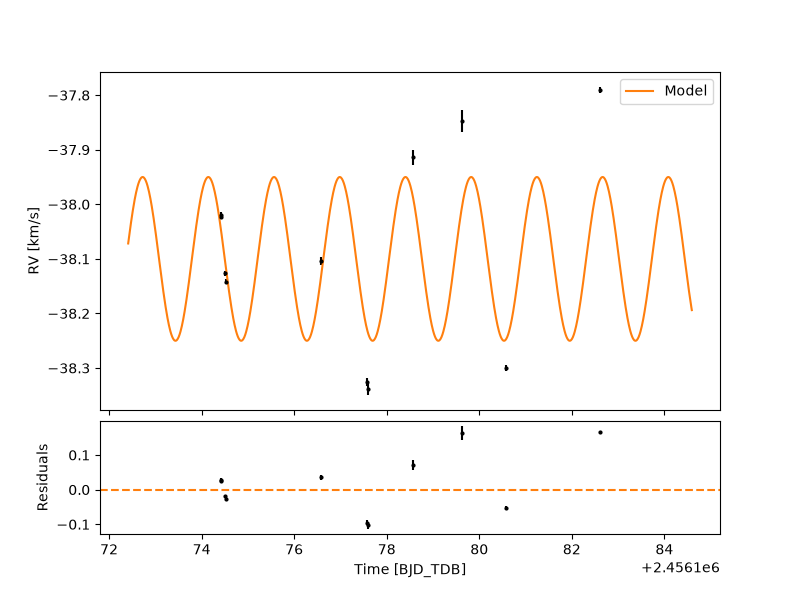

In [9]:
rv_model = theta[10] - theta[9] / 1000. * np.sin( 2 * np.pi * (data_rv['time'] - theta[0]) / theta[1])
rv_plot_x = np.arange(data_rv['time'][0]-2., data_rv['time'][-1]+2., 0.01)
rv_plot_y = theta[10] - theta[9] / 1000. * np.sin( 2 * np.pi * (rv_plot_x - theta[0]) / theta[1])
plt.xlabel('Time [BJD_TDB]')
plt.ylabel('RV')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.errorbar(data_rv['time'], data_rv['value'],yerr=data_rv['error'], fmt='o', color='k', markersize=2)

#ax_main.scatter(data_rv['time'], data_rv['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(rv_plot_x, rv_plot_y, color='C1', label='Model')

ax_main.set_ylabel('RV [km/s]')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)


# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.errorbar(data_rv['time'], data_rv['value']-rv_model,yerr=data_rv['error'], fmt='o', color='k', markersize=2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Time [BJD_TDB]')
ax_res.set_ylabel('Residuals')

plt.show()


## Log-likelihood

Let's compute the log-likelihood!

$\ln{\mathcal{L}} =  -0.5 \left[ N \ln{2 \pi} + \chi^2 + \sum\limits_{i=1}^{N}  \left( \ln{\sigma_i^2} \right) \right] $

We also have to add (in quadrature) the jitter to our estimated errors. 

We proceed by defining two likelihood functions, one for each dataset. Since wee are computing the logarithm of the likelihood, we will just need to sum the two values to compute the final log_likelihood.


In [10]:
def log_likelihood_photometry(theta):
    flux = tm.evaluate(t0=theta[0],
                    p=theta[1], 
                    k=theta[2],  
                    a=theta[3], 
                    i=theta[4]/180.*np.pi,
                    ldc=[theta[5], theta[6]])

    N = len(data_lc['value'])
    errors_with_jitter_added = data_lc['error']**2 + theta[8]**2

    chi2 =  np.sum((data_lc['value']-flux*theta[7])**2 / errors_with_jitter_added)

    sum_ln_sigma = np.sum(np.log(errors_with_jitter_added))

    log_likelihood_out = -0.5 * ( N * np.log(2*np.pi) + chi2 + sum_ln_sigma)
    if np.isnan(log_likelihood_out):
        log_likelihood_out = -np.inf 
    
    return log_likelihood_out

log_likelihood_photometry(theta)

np.float64(75869.49901932091)

In [11]:
def log_likelihood_radial_velocity(theta):
    rv_model = theta[10] - theta[9] / 1000. * np.sin( 
        2 * np.pi * (data_rv['time'] - theta[0]) / theta[1])

    N = len(data_rv['value'])
    errors_with_jitter_added = data_rv['error']**2 + theta[11]**2

    chi2 =  np.sum((data_rv['value']-rv_model)**2 / errors_with_jitter_added)

    sum_ln_sigma = np.sum(np.log(errors_with_jitter_added))

    log_likelihood_out = -0.5 * ( N * np.log(2*np.pi) + chi2 + sum_ln_sigma)
    if np.isnan(log_likelihood_out):
        log_likelihood_out = -np.inf 
    
    
    return log_likelihood_out

log_likelihood_radial_velocity(theta)

np.float64(-10.151156361439504)

## Define the priors

These are the limb darkening coefficients that I retrieved for this target when observed by TESS, using the parameters by [Bonomo et al. (2017)](https://ui.adsabs.harvard.edu/abs/2017A%26A...602A.107B/abstract) using the code LDTk by [Parviainen et al. 2015](https://ui.adsabs.harvard.edu/abs/2015MNRAS.453.3821P/abstract)  

- TESS LD coefficients   : $u1 = 0.51 \pm 0.05 \qquad   u2 = 0.10 \pm 0.10$

How do I incorporate this information in the computation of the posterior? 
The Bayes theorem says:

$$P \left(x|D \right) = \frac{P \left( D|x \right) P\left( x \right )}{P \left( D \right)}$$

Our sampler works by taking the natural logarithm of the likelihood, so priors can  be included easily by adding the logarithm of the probability density function of the parameters over which we want to impose a prior.

Depending on how much you trust your prior, you can keep the error estimate as predicted from theory or inflate the error associated with the median value according to other considerations. As an example, [Patel & Espinoza 2022](https://ui.adsabs.harvard.edu/abs/2022AJ....163..228P/abstract) argue that the error associated with a theoretical estimate of the limb darkening coefficients should be at least 0.1. 

The probability density function can be easily computed using `scipy`:

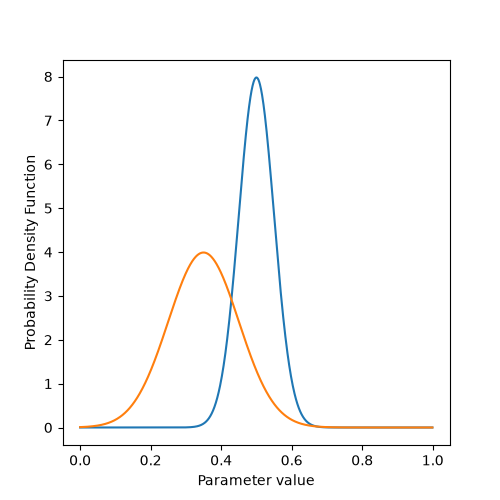

In [12]:
# prior on c1: 0.59 \pm 0.10
from scipy import stats

x_range=np.arange(0.00, 1.00, 0.001)
y1_plot = stats.norm.pdf(x_range, loc=0.50, scale=0.05)
y2_plot = stats.norm.pdf(x_range, loc=0.35, scale=0.10)
plt.figure(figsize=(5,5))
plt.plot(x_range, y1_plot)
plt.plot(x_range, y2_plot)
plt.xlabel('Parameter value')
plt.ylabel('Probability Density Function')
plt.show()

To correctly assign the prior, we need to keep track of the index associated with the parameters with explicit prior. 

Keep in mind that *all parameters* will have some kind of prior. If not explicitly stated, the prior is *uniform*, i.e., a constant value for the probability density distribution. 

In [13]:
def log_prior(theta):
    prior = 0.00
    prior += np.log (  stats.norm.pdf(theta[5], loc=0.51, scale=0.05))
    prior += np.log (  stats.norm.pdf(theta[6], loc=0.10, scale=0.10))
    return prior
print(log_prior(theta))

3.4404403001386914


## Log-probability

If we ignore the evidence term $P(D)$, which is independent of the value of the parameters, we can compute the log-probability by simply summing the log-likelihood with the log-prior. 

At this stage we can also perform a check on the boundaries

In [14]:
def log_probability(theta):

    sel = (theta <= boundaries[0,:]) | (theta >= boundaries[1,:])
    if np.sum(sel) > 0:
        return -np.inf

    log_prob = log_prior(theta)
    log_prob += log_likelihood_photometry(theta)
    log_prob += log_likelihood_radial_velocity(theta)
    
    return log_prob
print(log_probability(theta))

75862.78830325961


## Running the MCMC sample

To optimize the `log_likelihood` function, we are going to use the [Affine Invariant Markov chain Monte Carlo (MCMC) Ensemble sampler](https://msp.org/camcos/2010/5-1/p04.xhtml) called `emcee` ([Foreman-Mackey et al. 2013](https://ui.adsabs.harvard.edu/abs/2013PASP..125..306F/abstract), [GitHub page](https://github.com/dfm/emcee), [Documentation page](https://emcee.readthedocs.io/en/stable/)). 

To run `emcee`, we need to define:
- the number of *walkers*: `nwalkers`
- the number of *steps*: `nsteps` 
- the number of parameters: `ndim`

The number of walkers needs to be *at least* twice the number of parameters for the algorithm to work properly (this is a specific requirement of the affine invariant MCMC). The number of steps must be long enough for the chains to converge and mix. Note that:

- increasing the walker will make each iteration slower
- increasing the steps will make the total time longer 



In [17]:
nsteps = 20000
ngen = 50000
ndim = len(theta)
nwalkers = ndim*2


### Select the starting point

We also need to provide a starting point for the MCMC. 
We can safely use the `theta` that we have built earlier, with a caveat: the sampler requires each chain to be initialized at a slightly different position with respect to the other, so we are going to build an array with shape `(nwalkers, ndim)` by *perturbing* our starting point $\boldsymbol{\theta}$ by a small value. Since most of our starting values correspond to their lower boundary, we impose a positive perturbation for all variables (we could be selective, but the effort is not worth it). 

In [18]:
manual_starting_point = True
starting_point = theta + np.abs(1e-5 * np.random.randn(nwalkers, ndim))

Uncomment the following lines if you want to use the [PyDE - Differential evolution global optimization in Python](https://github.com/hpparvi/PyDE) code to search for the best starting point

In [20]:
# manual_starting_point = False
#from multiprocessing import Pool
#with Pool() as pool:
#    de = DiffEvol(log_probability, boundaries.T, nwalkers, maximize=True, pool=pool)
#    de.optimize(ngen)
#starting_point = de.population


In [21]:
np.shape(starting_point)
average_starting_point = np.average(starting_point, axis=0)
np.shape(average_starting_point)


(12,)

 Let's make a plot of the improved starting point

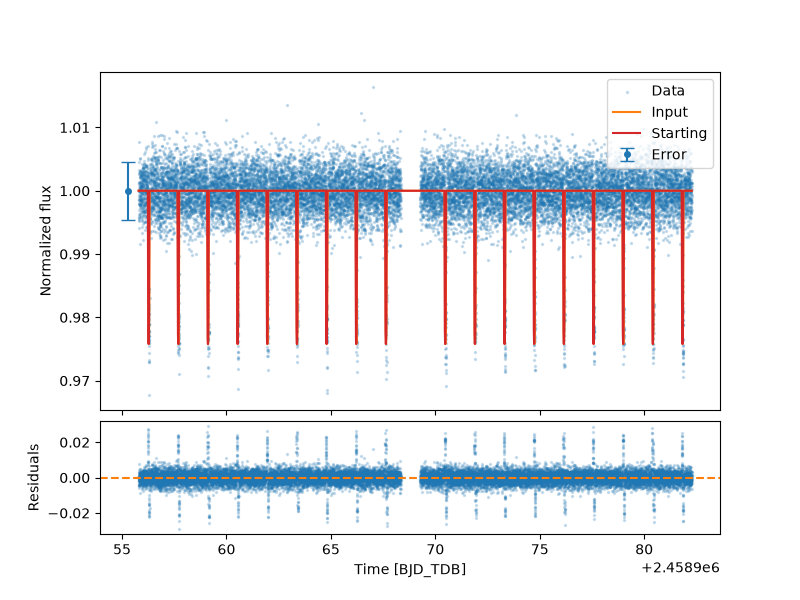

In [22]:
tm = RoadRunnerModel('quadratic')
tm.set_data(data_lc['time'])

input_model = tm.evaluate(t0=theta[0],
                    p=theta[1], 
                    k=theta[2],  
                    a=theta[3], 
                    i=theta[4]/180.*np.pi,
                    ldc=[theta[5], theta[6]])

starting_model = tm.evaluate(t0=average_starting_point[0],
                    p=average_starting_point[1], 
                    k=average_starting_point[2],  
                    a=average_starting_point[3], 
                    i=average_starting_point[4]/180.*np.pi,
                    ldc=[average_starting_point[5], average_starting_point[6]])


plt.xlabel('Time [BJD_TDB]')
plt.ylabel('Normalized flux')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.scatter(data_lc['time'], data_lc['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(data_lc['time'], input_model, color='C1', label='Input')
ax_main.plot(data_lc['time'], starting_model, color='C3', label='Starting')

# Plot single point with error bars
ax_main.errorbar(
    data_lc['time'][0]-0.5,
    1.0,
    yerr=np.median(data_lc['error']),
    fmt='o',          # marker style
    capsize=5,        # size of error bar caps
    markersize=4,
    label='Error'
)
ax_main.set_ylabel('Normalized flux')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)



# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.scatter(data_lc['time'], data_lc['value']-starting_model,  s=2, alpha=0.2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Time [BJD_TDB]')
ax_res.set_ylabel('Residuals')

plt.show()


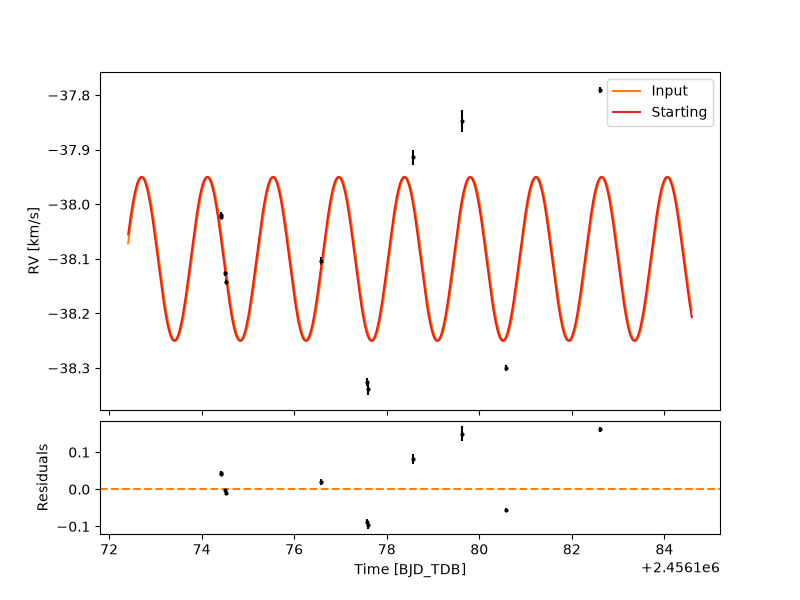

In [23]:
rv_model = average_starting_point[10] - average_starting_point[9] / 1000. * np.sin( 2 * np.pi * (data_rv['time'] - average_starting_point[0]) / average_starting_point[1])

rv_plot_x_starting = np.arange(data_rv['time'][0]-2., data_rv['time'][-1]+2., 0.01)
rv_plot_y_starting = average_starting_point[10] - average_starting_point[9] / 1000. * np.sin( 2 * np.pi * (rv_plot_x_starting - average_starting_point[0]) / average_starting_point[1])

rv_plot_x_input= np.arange(data_rv['time'][0]-2., data_rv['time'][-1]+2., 0.01)
rv_plot_y_input = theta[10] - theta[9] / 1000. * np.sin( 2 * np.pi * (rv_plot_x_input - theta[0]) / theta[1])

plt.xlabel('Time [BJD_TDB]')
plt.ylabel('RV')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.errorbar(data_rv['time'], data_rv['value'],yerr=data_rv['error'], fmt='o', color='k', markersize=2)

#ax_main.scatter(data_rv['time'], data_rv['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(rv_plot_x_input, rv_plot_y_input, color='C1', label='Input')
ax_main.plot(rv_plot_x_starting, rv_plot_y_starting, color='C3', label='Starting')

ax_main.set_ylabel('RV [km/s]')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)


# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.errorbar(data_rv['time'], data_rv['value']-rv_model,yerr=data_rv['error'], fmt='o', color='k', markersize=2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Time [BJD_TDB]')
ax_res.set_ylabel('Residuals')
plt.show()


In [26]:
from multiprocessing import Pool
with Pool() as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, pool=pool)
    sampler.run_mcmc(starting_point, nsteps, progress=True)

100%|█████████████████████████████████████████████████████████████████████████████| 20000/20000 [03:47<00:00, 87.93it/s]


In [29]:
if manual_starting_point:
    pickle.dump(sampler, open('emcee_sampler_photometry_radialvelocity_manual_starting_point.p','wb'))
else:
    pickle.dump(sampler, open('emcee_sampler_photometry_radialvelocity.p','wb'))


## Analysis of the results

We can visualize the chain to verify that the MCMC has reached convergence. Only four parameters are shown in this example, for your analysis you must check them all. 

**Note** to reload the pickle files from a previous run, you must compile also the log-probability / log-likelihood / log-priors functions.
The easiest way to do it is to run again the entire jupyter notebook *after commenting the emcee analysis* and * the part where files are saved*

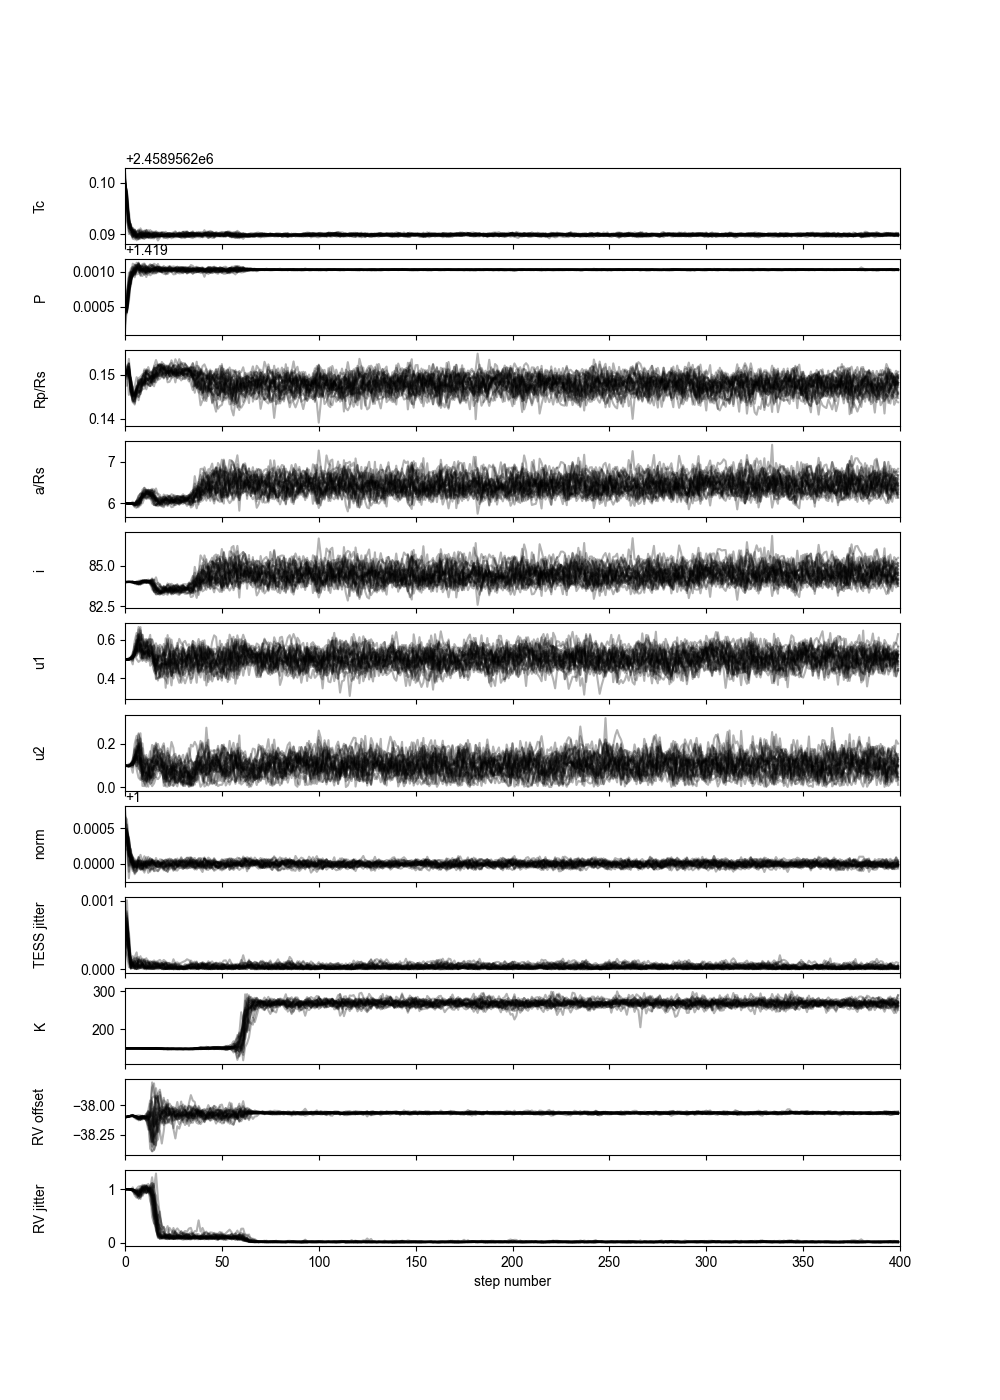

In [32]:
if manual_starting_point:
    sampler = pickle.load(open('emcee_sampler_photometry_radialvelocity_manual_starting_point.p','rb'))
else:
    sampler = pickle.load(open('emcee_sampler_photometry_radialvelocity.p','rb'))


fig, axes = plt.subplots(ndim, figsize=(10, 14), sharex=True)
samples = sampler.get_chain(thin=50)  # We apply a thinning factor to make the plot faster to render

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number (divided by 50)")
plt.show()


To extract the chains from the output, we rely on the help provided by the documentation. 
After applying the burn-in cut and thinning the chains, We analyse the chain every n_subsample*thin number of steps. Remember the convergence criterion: *Convergence criterion: any of the moments (e.g. the mean or standard deviation) of the posterior distribution is independent of the choice of the steps or the chains used to build the posterior*


(300, 24, 12)
range      0 to      40, mean: 2458956.289915  std: 0.000173
range     40 to      80, mean variation:  0.0  std variation: -3.5
range     80 to     120, mean variation: -0.0  std variation:  1.5
range    120 to     160, mean variation: -0.0  std variation: -4.9
range    160 to     200, mean variation:  0.0  std variation:  2.5
range    200 to     240, mean variation: -0.0  std variation: -4.5
range    240 to     280, mean variation: -0.0  std variation:  0.6
range    280 to     320, mean variation:  0.0  std variation: 10.2


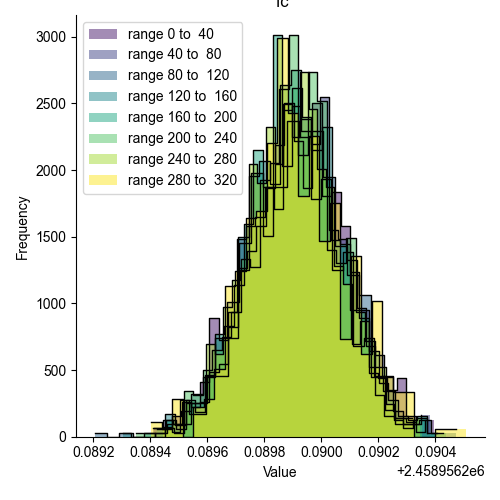

range      0 to      40, mean: 1.420027  std: 0.000003
range     40 to      80, mean variation:  0.0  std variation:  2.0
range     80 to     120, mean variation: -0.0  std variation: 11.5
range    120 to     160, mean variation:  0.0  std variation: -8.2
range    160 to     200, mean variation: -0.0  std variation:  3.6
range    200 to     240, mean variation: -0.0  std variation:  2.0
range    240 to     280, mean variation:  0.0  std variation: -9.5
range    280 to     320, mean variation: -0.0  std variation: 31.8


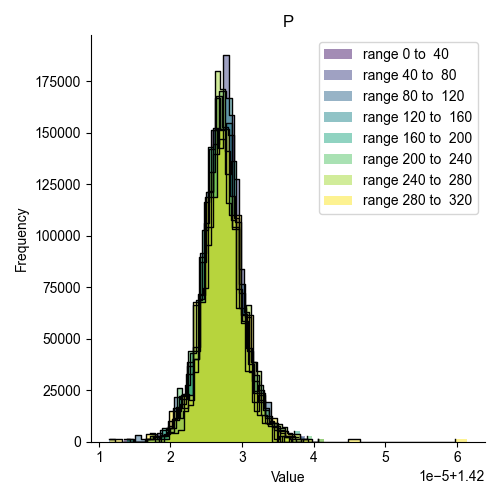

range      0 to      40, mean: 0.147765  std: 0.001952
range     40 to      80, mean variation:  0.1  std variation:  2.2
range     80 to     120, mean variation:  0.0  std variation: -3.1
range    120 to     160, mean variation: -0.2  std variation:  1.1
range    160 to     200, mean variation:  0.1  std variation: -1.6
range    200 to     240, mean variation: -0.2  std variation:  0.0
range    240 to     280, mean variation:  0.0  std variation:  3.3
range    280 to     320, mean variation:  0.0  std variation: -4.0


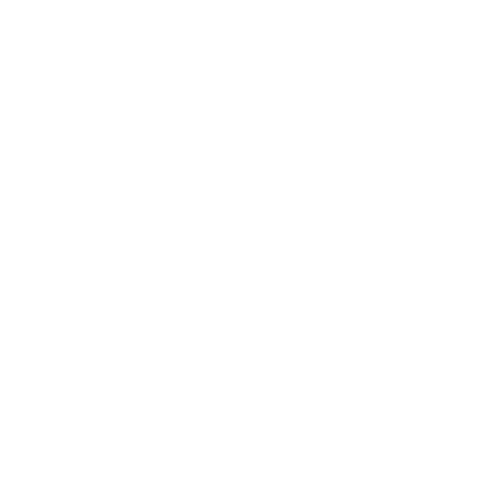

range      0 to      40, mean: 6.437984  std: 0.219767
range     40 to      80, mean variation: -0.0  std variation: -1.5
range     80 to     120, mean variation: -0.1  std variation: -3.0
range    120 to     160, mean variation:  0.2  std variation: -0.3
range    160 to     200, mean variation: -0.0  std variation:  1.3
range    200 to     240, mean variation:  0.6  std variation:  2.8
range    240 to     280, mean variation: -0.3  std variation: -1.3
range    280 to     320, mean variation:  0.0  std variation: -1.8


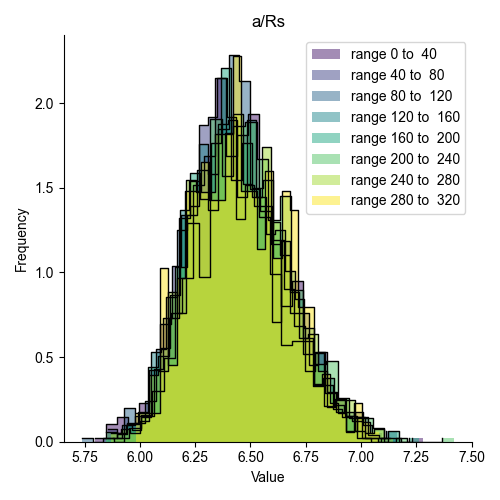

range      0 to      40, mean: 84.460059  std: 0.543016
range     40 to      80, mean variation: -0.0  std variation: -1.1
range     80 to     120, mean variation: -0.0  std variation: -2.8
range    120 to     160, mean variation:  0.0  std variation:  0.8
range    160 to     200, mean variation: -0.0  std variation: -0.9
range    200 to     240, mean variation:  0.1  std variation:  4.0
range    240 to     280, mean variation: -0.1  std variation: -1.0
range    280 to     320, mean variation:  0.0  std variation: -2.7


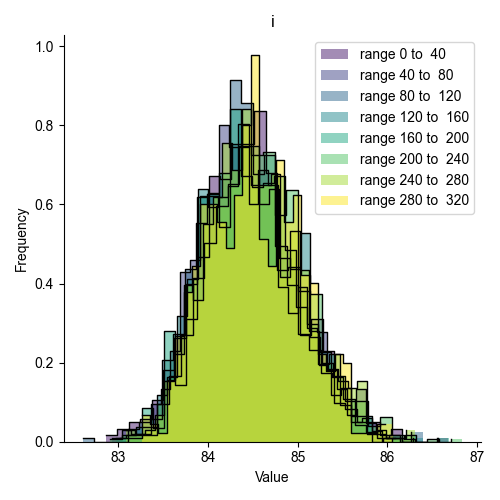

range      0 to      40, mean: 0.499118  std: 0.047227
range     40 to      80, mean variation: -0.7  std variation: -1.6
range     80 to     120, mean variation:  2.2  std variation:  1.1
range    120 to     160, mean variation: -1.4  std variation:  0.6
range    160 to     200, mean variation: -0.1  std variation: -0.5
range    200 to     240, mean variation:  1.4  std variation:  5.9
range    240 to     280, mean variation:  0.3  std variation: -6.1
range    280 to     320, mean variation: -0.7  std variation: -8.6


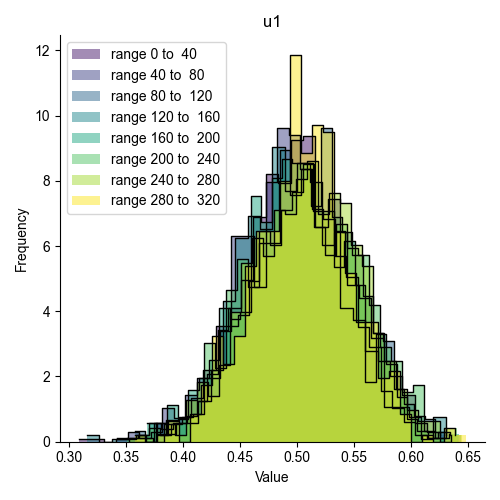

range      0 to      40, mean: 0.104549  std: 0.044393
range     40 to      80, mean variation: -4.2  std variation:  5.5
range     80 to     120, mean variation: -4.1  std variation: -6.3
range    120 to     160, mean variation: 12.5  std variation: 10.1
range    160 to     200, mean variation: -3.9  std variation: -8.1
range    200 to     240, mean variation:  1.2  std variation:  4.5
range    240 to     280, mean variation: -4.5  std variation:  0.3
range    280 to     320, mean variation:  3.1  std variation: -4.1


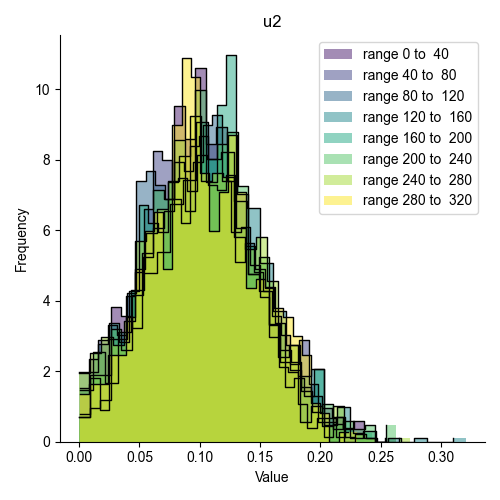

range      0 to      40, mean: 0.999995  std: 0.000032
range     40 to      80, mean variation:  0.0  std variation:  2.6
range     80 to     120, mean variation:  0.0  std variation:  2.4
range    120 to     160, mean variation: -0.0  std variation:  3.8
range    160 to     200, mean variation:  0.0  std variation: -0.6
range    200 to     240, mean variation: -0.0  std variation:  2.2
range    240 to     280, mean variation: -0.0  std variation: -4.6
range    280 to     320, mean variation: -0.0  std variation:  0.7


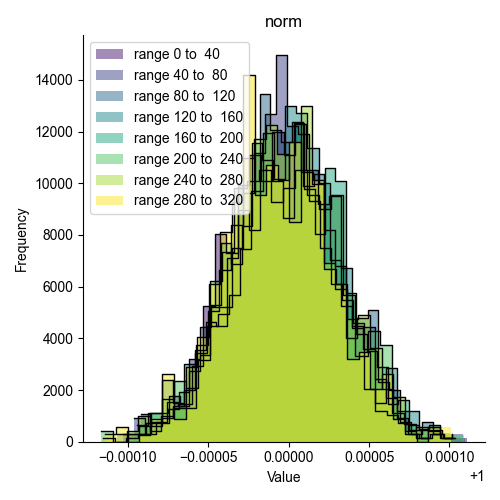

range      0 to      40, mean: 0.000034  std: 0.000027
range     40 to      80, mean variation: 11.5  std variation:  7.1
range     80 to     120, mean variation: -7.2  std variation: -7.2
range    120 to     160, mean variation:  3.9  std variation: 10.2
range    160 to     200, mean variation: -3.8  std variation: -12.2
range    200 to     240, mean variation:  5.3  std variation:  9.0
range    240 to     280, mean variation: -16.1  std variation: -11.7
range    280 to     320, mean variation:  1.6  std variation: -0.7


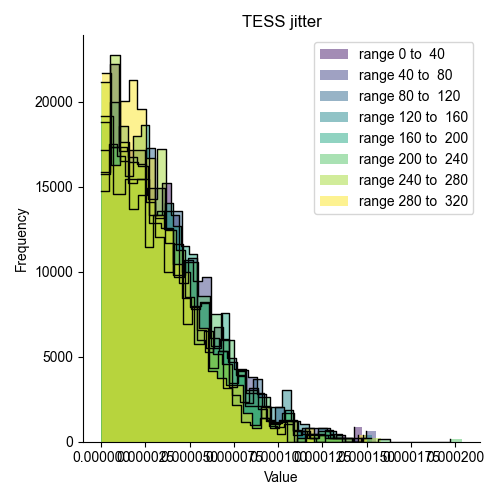

range      0 to      40, mean: 268.956815  std: 7.340602
range     40 to      80, mean variation: -0.2  std variation: -6.8
range     80 to     120, mean variation: -0.4  std variation: 16.9
range    120 to     160, mean variation:  0.4  std variation: -7.0
range    160 to     200, mean variation:  0.1  std variation:  7.4
range    200 to     240, mean variation: -0.1  std variation: -8.3
range    240 to     280, mean variation: -0.1  std variation: -4.7
range    280 to     320, mean variation: -0.1  std variation:  4.1


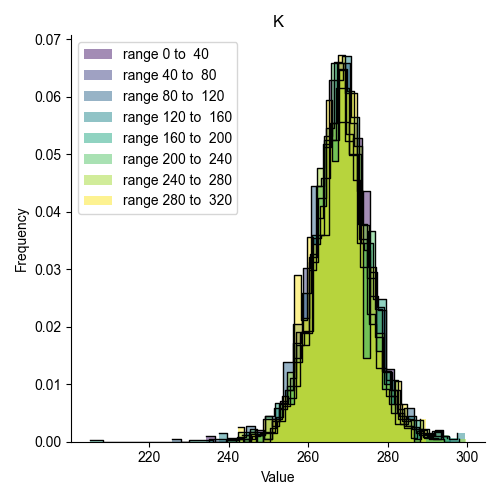

range      0 to      40, mean: -38.065635  std: 0.005670
range     40 to      80, mean variation: -0.0  std variation: -6.8
range     80 to     120, mean variation:  0.0  std variation:  3.3
range    120 to     160, mean variation:  0.0  std variation:  0.1
range    160 to     200, mean variation: -0.0  std variation: -3.3
range    200 to     240, mean variation:  0.0  std variation:  7.1
range    240 to     280, mean variation: -0.0  std variation: -10.1
range    280 to     320, mean variation:  0.0  std variation:  0.9


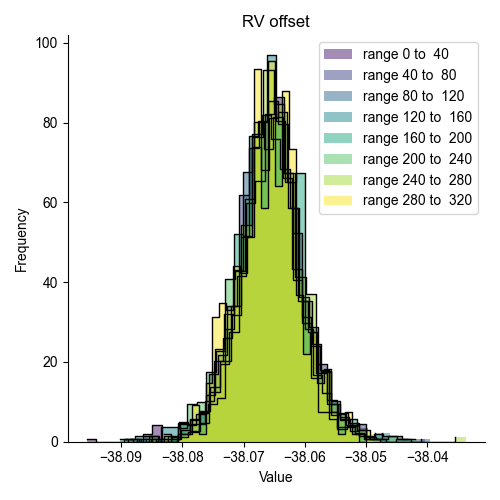

range      0 to      40, mean: 0.012498  std: 0.006204
range     40 to      80, mean variation: -3.3  std variation: -8.8
range     80 to     120, mean variation:  6.1  std variation:  7.0
range    120 to     160, mean variation: -1.5  std variation: -3.1
range    160 to     200, mean variation: -3.6  std variation: -8.8
range    200 to     240, mean variation:  5.8  std variation:  2.3
range    240 to     280, mean variation: -5.2  std variation:  7.0
range    280 to     320, mean variation:  0.7  std variation: -4.8


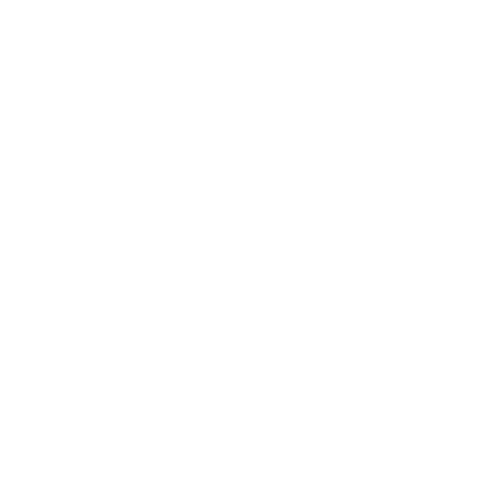

In [35]:
chain_samples = sampler.get_chain(discard=5000, thin=50, flat=False)
print(chain_samples.shape)

n_subsample = 40


for i in range(ndim):
    
    # Create figure
    fig, ax = plt.subplots(figsize=(5, 5))
    
    color_index = np.linspace(0, 1, int(chain_samples.shape[0]/n_subsample))
    # Colormap setup
    cmap = plt.cm.viridis
    
    for ii in range(0, chain_samples.shape[0], n_subsample):
        select_chain_samples = chain_samples[ii: ii+n_subsample, :, i]
        
        color = cmap( (ii + ii + n_subsample)/(2*chain_samples.shape[0]))
        # Histogram:
        # - facecolor gives the shaded fill
        # - linewidth controls the outer border thickness
        # - edgecolor='none' removes borders around individual bars
        counts, bins, patches = ax.hist(
            select_chain_samples.flatten(),
            bins=30,
            facecolor=color,
            edgecolor='none',
            alpha=0.5,
            label = 'range {0:.0f} to  {1:.0f}'.format(ii, ii+ n_subsample),
            density=True
        )
        
        # Draw a thick outline around the whole histogram shape
        ax.step(
            bins[:-1],
            counts,
            where='post',
            linewidth=1,
            color='black',
        )
        if ii == 0:

            print('range {0:6.0f} to  {1:6.0f}, mean: {2:.6f}  std: {3:.6f}'.format(
                ii, ii+ n_subsample, np.average(select_chain_samples), np.std(select_chain_samples)) )
        else:
            average_variation = np.average(select_chain_samples)/previous_average-1.
            std_variation = np.std(select_chain_samples)/previous_std-1.
            print('range {0:6.0f} to  {1:6.0f}, mean variation: {2:4.1f}  std variation: {3:4.1f}'.format(
                ii, ii+ n_subsample,average_variation*100., std_variation*100.) )
        previous_average = np.average(select_chain_samples)
        previous_std = np.std(select_chain_samples)
    # Labels and styling
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(labels[i])
    ax.legend()
    # Optional: cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    

After applying the burn-in cut and thinning the chains, the chains of each parameter are all merged into a *flat* distribution. We are using this one to estimate the error for each parameter.


In [36]:
flat_samples = sampler.get_chain(discard=2000, thin=50, flat=True)
print(flat_samples.shape)
n_samples = flat_samples.shape[0] 

(8640, 12)


In [37]:
for i, par_name in enumerate(labels):
    theta_med = compute_value_sigma(flat_samples[:, i])
    s0, s1 = return_significant_figures(theta_med[0], theta_med[2], theta_med[1])
    format_string_long = '{0:12s}  {1:4d}  {2:12.'+repr(max(s0,s1))+'f} {3:12.'+repr(s0)+'f} {4:12.'+repr(s1)+'f}   (15-84 p)   [{5:10.4f}, {6:10.4f}]'
    print(format_string_long.format(
        par_name, i, theta_med[0], theta_med[2], theta_med[1], boundaries[0, i], boundaries[1, i]))


Tc               0  2458956.28990     -0.00017      0.00017   (15-84 p)   [2458956.2000, 2458956.4000]
P                1     1.4200272   -0.0000029    0.0000031   (15-84 p)   [    1.3200,     1.5200]
Rp/Rs            2        0.1478      -0.0021       0.0018   (15-84 p)   [    0.0000,     0.5000]
a/Rs             3          6.43        -0.20         0.23   (15-84 p)   [    0.0000,    20.0000]
i                4         84.45        -0.50         0.57   (15-84 p)   [   80.0000,    90.0000]
u1               5         0.502       -0.048        0.048   (15-84 p)   [   -1.0000,     1.0000]
u2               6         0.102       -0.047        0.046   (15-84 p)   [    0.0000,     1.0000]
norm             7      0.999998    -0.000034     0.000034   (15-84 p)   [    0.9000,     1.1000]
TESS jitter      8      0.000030    -0.000021     0.000033   (15-84 p)   [    0.0000,     0.0100]
K                9         267.6         -8.6          7.0   (15-84 p)   [    0.0000,   300.0000]
RV offset      

We can plot the corner plot, highlighting possible correlations between parameters and non-Gaussian posterior distributions. Make some effort to improve the quality of this plot, by following the example provided in the [documentation of the code](https://corner.readthedocs.io/en/latest/) or using a different code, such as [pygtc](https://pygtc.readthedocs.io/en/latest/)

In [39]:
# List of parameter names, supports latex
# NOTE: For capital greek letters in latex mode, use \mathsf{}

# List of Gaussian curves to plot
#(to represent priors): mean, width
# Empty () or None if no prior to plot
priors = ((),
          (),
          (),
          (),
          (),
          (0.50, 0.05),
          (0.10, 0.05),
          (),
         (),
         (),
         (),
         ())

# List of truth values, to mark best-fit or input values
# NOT a python array because of different lengths
# Here we choose two sets of truth values
#truths = ((4, .5, None, .1, 0, None, None, 0),
#          (None, None, .3, 1, None, None, None, None))

# Labels for the different truths
#truthLabels = ( 'the truth',
#               'also true')

# Do the magic
GTC = pygtc.plotGTC(chains=flat_samples,
                    paramNames=labels,
                    #chainLabels=chainLabels,
                    #truths=truths,
                    #truthLabels=truthLabels,
                    priors=priors,
                    figureSize='MNRAS_page',
                    plotName='corner_transit_rv.pdf')

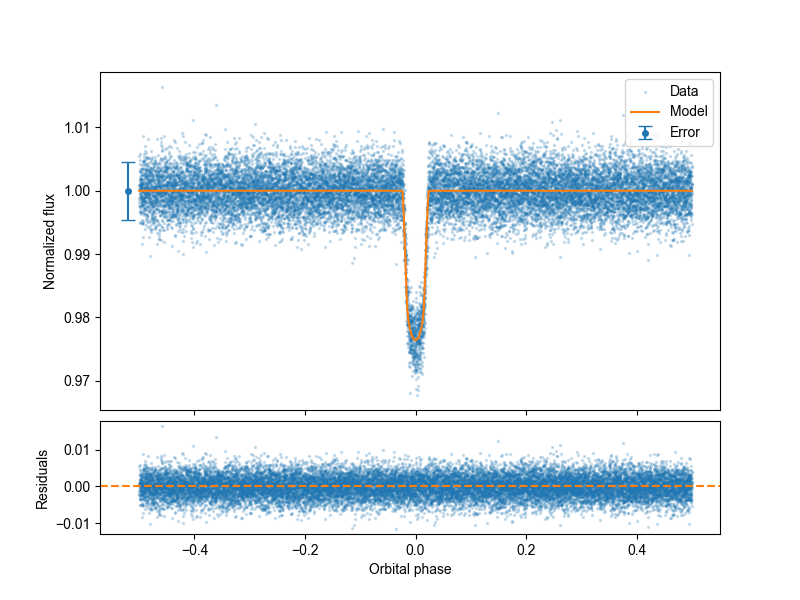

In [44]:
averaged_results = np.median(flat_samples, axis=0)

folded_tess_time = (data_lc['time'] -averaged_results[0] - averaged_results[1]/2. ) % averaged_results[1] - averaged_results[1]/2. 
folded_range = np.arange(- averaged_results[1]/2.,  averaged_results[1]/2., 0.001)


tm = RoadRunnerModel('quadratic')
tm.set_data(data_lc['time'])

input_model = tm.evaluate(t0=averaged_results[0],
                    p=averaged_results[1], 
                    k=averaged_results[2],  
                    a=averaged_results[3], 
                    i=averaged_results[4]/180.*np.pi,
                    ldc=[averaged_results[5], averaged_results[6]])
plot_tm = RoadRunnerModel('quadratic')
plot_tm.set_data(folded_range)
plot_model = plot_tm.evaluate(t0=0,
                    p=averaged_results[1], 
                    k=averaged_results[2],  
                    a=averaged_results[3], 
                    i=averaged_results[4]/180.*np.pi,
                    ldc=[averaged_results[5], averaged_results[6]])

plt.xlabel('Orbital phase')
plt.ylabel('Normalized flux')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.scatter(folded_tess_time/ averaged_results[1], data_lc['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(folded_range/ averaged_results[1], plot_model, color='C1', label='Model')

# Plot single point with error bars
ax_main.errorbar(
    -0.52,
    1.0,
    yerr=np.median(data_lc['error']),
    fmt='o',          # marker style
    capsize=5,        # size of error bar caps
    markersize=4,
    label='Error'
)
ax_main.set_ylabel('Normalized flux')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)


# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.scatter(folded_tess_time/ averaged_results[1], data_lc['value']-input_model,  s=2, alpha=0.2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Orbital phase')
ax_res.set_ylabel('Residuals')

plt.show()

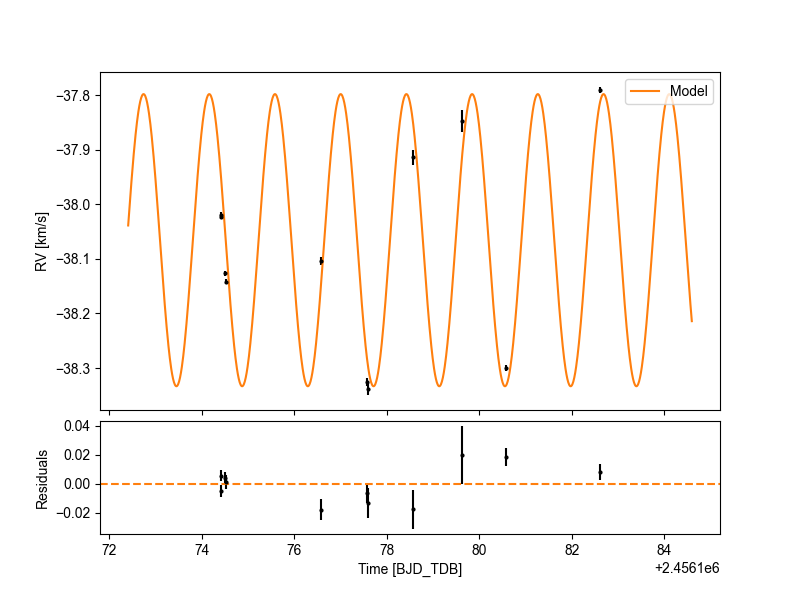

In [45]:
rv_model = averaged_results[10] - averaged_results[9] / 1000. * np.sin( 2 * np.pi * (data_rv['time'] - averaged_results[0]) / averaged_results[1])
rv_plot_x = np.arange(data_rv['time'][0]-2., data_rv['time'][-1]+2., 0.01)
rv_plot_y = averaged_results[10] - averaged_results[9] / 1000. * np.sin( 2 * np.pi * (rv_plot_x - theta[0]) / theta[1])
plt.xlabel('Time [BJD_TDB]')
plt.ylabel('RV')
# Create figure
fig = plt.figure(figsize=(8, 6))

# Define subplot layout
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.errorbar(data_rv['time'], data_rv['value'],yerr=data_rv['error'], fmt='o', color='k', markersize=2)

#ax_main.scatter(data_rv['time'], data_rv['value'], s=2, alpha=0.2, label='Data')
ax_main.plot(rv_plot_x, rv_plot_y, color='C1', label='Model')

ax_main.set_ylabel('RV [km/s]')
ax_main.legend(loc='upper right')
ax_main.tick_params(labelbottom=False)


# Residuals subplot
ax_res = fig.add_subplot(gs[1], sharex=ax_main)
ax_res.errorbar(data_rv['time'], data_rv['value']-rv_model,yerr=data_rv['error'], fmt='o', color='k', markersize=2)
ax_res.axhline(0, color='C1', linestyle='--')
ax_res.set_xlabel('Time [BJD_TDB]')
ax_res.set_ylabel('Residuals')

plt.show()

You can finally obtain any derived parameters from your posteriors. For example, to get the planetary radius in physical units, you need to multiply the scaled planetary radius (from the fit) by the stellar radius in solar units (from the literature) and then  multiply it by the ratio of the radii between the Sun and Jupyter to get the value in Jupiter radii. You can easily account for the error associated with the stellar radius by creating a Normal distribution with the same size as the number of samples and a standard deviation equal to the associated error (assuming a normal symmetric distribution).


In [46]:
# derived parameters:
# stellar radius: 0.800±0.050 solar radius
# stellar mass: 0.850±0.030 solar mass
"""
theta[0] = 2458956.30  #time of inferior conjunction
theta[1] = 1.4200      #orbital period
theta[2] = 0.150       #planet radius (in units of stellar radii)
theta[3] = 6.00        #semi-major axis (in units of stellar radii)
theta[4] = 84.0        #orbital inclination (in degrees)
theta[5] = 0.50        # TESS LD coeff u1
theta[6] = 0.10        # TESS LD coeff u2
theta[7] = 1.00        # normalization factor
theta[8] = 0.0001      # jitter parameter for TESS data
theta[9] = 150.0      # RV semiamplitude in m/s
theta[10] = -38.1       # RV offset in km/s
theta[11] = 1.0      # jitter parameter for RV data
"""

stellar_mass = np.random.normal(0.850, 0.030, n_samples)
stellar_radius = np.random.normal(0.800, 0.050, n_samples )
# def kepler_get_planet_mass(period, rv_semiamplitude, ecc, mass_star, approximation_limit=30.):
planet_mass = kepler_get_planet_mass(flat_samples[:,1], flat_samples[:,9], np.zeros(n_samples),  stellar_mass) * Msjup
planet_radius = flat_samples[:,2]*stellar_radius * Rsjup

Computing exact mass of the planet (mean of approximate mass distribution larger than 30.0 Me)


In [47]:
planet_mass_med = compute_value_sigma(planet_mass)
s0, s1 = return_significant_figures(planet_mass_med[0], planet_mass_med[2], planet_mass_med[1])
format_string_long = 'planet mass [Mj]   {0:12.'+repr(max(s0,s1))+'f} {1:12.'+repr(s0)+'f} {2:12.'+repr(s1)+'f}   (15-84 p)'
print(format_string_long.format(planet_mass_med[0], planet_mass_med[2], planet_mass_med[1]))

planet_radius_med = compute_value_sigma(planet_radius)
s0, s1 = return_significant_figures(planet_radius_med[0], planet_radius_med[2], planet_radius_med[1])
format_string_long = 'planet radius [Rj] {0:12.'+repr(max(s0,s1))+'f} {1:12.'+repr(s0)+'f} {2:12.'+repr(s1)+'f}   (15-84 p)'
print(format_string_long.format(planet_radius_med[0], planet_radius_med[2], planet_radius_med[1]))


planet mass [Mj]          1.327       -0.058        0.049   (15-84 p)
planet radius [Rj]        1.150       -0.074        0.072   (15-84 p)
